<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
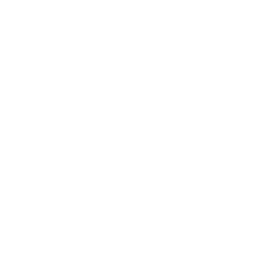
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Intervalles de Confiance Bootstrap pour les Critères d'Essais Cliniques</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Biostatistique Pharmaceutique / Clinique &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Résumé Exécutif

Cet exemple travaillé calcule un **intervalle de confiance bootstrap non paramétrique** pour un critère de survie à l'aide de **PROC IML**, le langage de programmation matricielle de SAS. Le critère est le **rapport des médianes de survie sans progression (SSP)** entre les bras traitement et contrôle d'une petite cohorte oncologique à deux bras.

Le programme IML lit les données au niveau du sujet dans des matrices, calcule le rapport observé des SSP médianes, tire **2 000 rééchantillonnages bootstrap** avec remise à l'aide de `CALL RANDGEN`, recalcule le rapport dans chaque rééchantillonnage par des opérations matricielles, et dérive un intervalle de confiance **corrigé du biais et accéléré (BCa)**. BCa est le choix approprié ici car la distribution bootstrap d'un rapport de médianes est bornée inférieurement par zéro, discrète, et asymétrique — des conditions dans lesquelles un intervalle normal-théorique simple n'est pas fiable.

L'analyse s'exécute entièrement dans IML : la constante de correction de biais *z*<sub>0</sub>, l'accélération *a&#770;* issue d'un jackknife leave-one-out, et les bornes percentiles ajustées sont toutes assemblées à partir d'expressions matricielles et des fonctions normales standard `PROBNORM` et un petit module de fonction normale inverse. Chaque chiffre rapporté ci-dessous est lu directement dans la sortie IML.

## Sources des Données

| Source | Description | Enregistrements |
|--------|-------------|---------|
| WORK.TRIAL_SUBJECTS | Temps de SSP par sujet, indicateur d'événement, bras de traitement, et covariables initiales | 100 |

La cohorte est **équilibrée** — 50 sujets par bras — en assignant l'appartenance au bras selon la parité de l'identifiant du sujet, de sorte que les deux bras soient pleinement représentés dans le rééchantillonnage.

---


In [1]:
/* --------------------------------------------------------
   Générer une cohorte oncologique synthétique à deux bras.
   Les temps de SSP suivent une loi log-normale ; le bras traitement
   est décalé vers une médiane plus longue. L'appartenance au bras
   alterne selon la parité de l'identifiant du sujet, pour une
   cohorte équilibrée 50/50.
   -------------------------------------------------------- */
DONNÉES work.trial_subjects;
    LONGUEUR arm_label $12;
    APPELER streaminit(42);
    FAIRE subject_id = 1 JUSQU_À 500;
        /* 1 = Traitement, 0 = Contrôle (équilibré par parité) */
        arm = mod(subject_id, 2);
        arm_label = ifc(arm = 1, 'TRAITEMENT', 'CONTRÔLE');
        /* Temps de SSP en mois : le bras traitement a une survie plus longue */
        SI arm = 1 ALORS
            pfs_months = round(rand('lognormal', LOG(12.5), 0.65), 0.1);
        SINON
            pfs_months = round(rand('lognormal', LOG(8.2),  0.70), 0.1);
        SI pfs_months < 0.5 ALORS pfs_months = 0.5;
        /* Indicateur d'événement : ~75% des sujets ont eu un événement de progression */
        EVENT = (rand('uniform') > 0.25);
        /* Covariables initiales */
        ecog_ps = int(rand('uniform') * 3);   /* 0, 1, 2 */
        AGE = int(rand('normal', 62, 11));
        SI AGE < 25 ALORS AGE = 25;
        SI AGE > 85 ALORS AGE = 85;
        SORTIE;
    FIN;
EXÉCUTER;


NOTE: DATA work.trial_subjects

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_subjects (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---


                              Résumé de la Survie Sans Progression par Bras de Traitement                               

                                                  The MEANS Procedure

                                       Analysis Variable : pfs_months SSP (mois)

        Bras de Traitement          N Obs           Mean         Median        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------------------------
        CONTRÔLE                       50          10.74           7.20           9.86           1.90          53.70
        TRAITEMENT                     50          13.94          10.10          11.95           2.70          79.10
        ------------------------------------------------------------------------------------------------------------

                                              Analysis Variable : AGE Âge

        Bras de Traitement          N Obs           Mean        


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_label_event.spec.json
NOTE: PROC FREQ statement used.


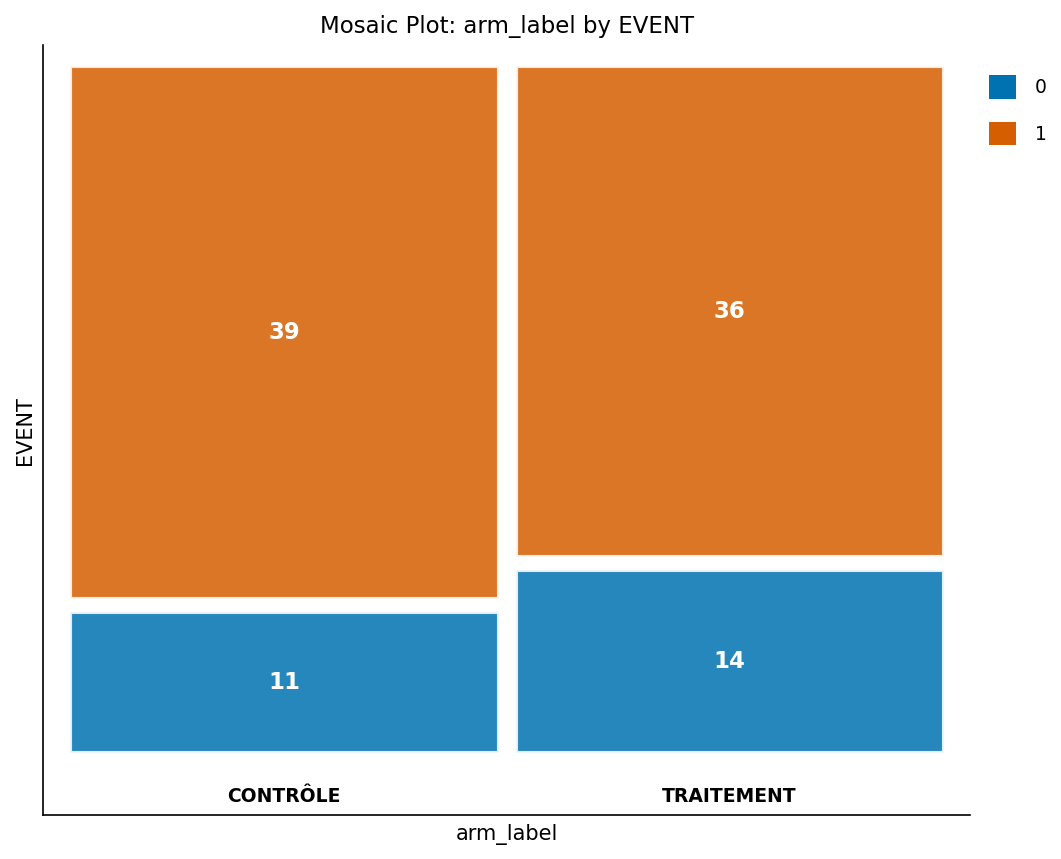

In [2]:
/* --------------------------------------------------------
   Résumé de la SSP initiale et taux d'événements par bras de traitement
   -------------------------------------------------------- */
PROCÉDURE MEANS DONNÉES=work.trial_subjects n mean MEDIAN std MIN MAX maxdec=2;
    CLASSE arm_label;
    VAR pfs_months AGE;
    ÉTIQUETTE arm_label='Bras de Traitement' pfs_months='SSP (mois)' AGE='Âge';
    TITRE 'Résumé de la Survie Sans Progression par Bras de Traitement';
EXÉCUTER;

PROCÉDURE FREQ DONNÉES=work.trial_subjects;
    TABLES arm_label * EVENT / nocol nopercent;
    ÉTIQUETTE arm_label='Bras de Traitement' EVENT='Événement';
    TITRE "Nombre d'Événements par Bras de Traitement";
EXÉCUTER;

---


In [3]:
/* --------------------------------------------------------
   PROC IML : bootstrap non paramétrique pour le rapport de
   SSP médiane, avec un intervalle de confiance BCa.

   Étapes :
   1. Lire les données de l'essai dans des matrices IML
   2. Calculer le rapport observé des SSP médianes (temps d'événement)
   3. Tirer 2 000 rééchantillonnages bootstrap avec CALL RANDGEN
   4. Recalculer le rapport dans chaque rééchantillonnage
   5. Correction BCa : z0 (biais) + accélération jackknife
   6. Écrire la distribution bootstrap dans un jeu de données SAS
   -------------------------------------------------------- */
PROCÉDURE IML;

    /* --- Module : SSP médiane par bras et leur rapport --- */
    /* La médiane est calculée sur les temps d'événement observés
       seulement, le résumé non paramétrique usuel lorsque la
       plupart des sujets progressent. */
    START calc_stats(pfs, arm, EVENT);
        trt_pfs = pfs[loc(arm = 1 & EVENT = 1)];
        ctl_pfs = pfs[loc(arm = 0 & EVENT = 1)];
        SI nrow(trt_pfs) = 0 ALORS trt_med = .;
        SINON trt_med = MEDIAN(trt_pfs);
        SI nrow(ctl_pfs) = 0 ALORS ctl_med = .;
        SINON ctl_med = MEDIAN(ctl_pfs);
        SI ctl_med > 0 & trt_med ^= . & ctl_med ^= .
            ALORS RATIO = trt_med / ctl_med;
        SINON RATIO = .;
        RETURN (trt_med || ctl_med || RATIO);
    FINISH;

    /* --- Module : CDF normale standard inverse (probit) --- */
    /* Approximation rationnelle (Abramowitz & Stegun 26.2.23) ;
       associée à PROBNORM elle fournit les bornes z0 / z-alpha
       dont l'ajustement BCa a besoin. */
    START probit(p);
        SI p <= 0 ALORS RETURN(-1e8);
        SI p >= 1 ALORS RETURN( 1e8);
        SI p < 0.5 ALORS FAIRE; sgn = -1; pp = p;     FIN;
        SINON            FAIRE; sgn =  1; pp = 1 - p; FIN;
        t   = sqrt(-2 * LOG(pp));
        num = 2.515517 + 0.802853*t + 0.010328*t*t;
        den = 1 + 1.432788*t + 0.189269*t*t + 0.001308*t*t*t;
        RETURN (sgn * (t - num/den));
    FINISH;

    /* --- 1. Charger les données dans des matrices --- */
    USE work.trial_subjects;
        READ TOUT VAR {pfs_months} VERS pfs;
        READ TOUT VAR {arm}        VERS arm;
        READ TOUT VAR {EVENT}      VERS ev;
    CLOSE work.trial_subjects;
    n     = nrow(pfs);
    n_trt = sum(arm = 1);
    n_ctl = sum(arm = 0);
    IMPRIMER 'Sujets lus dans IML', n n_trt n_ctl;

    /* --- 2. Statistique observée sur l'échantillon complet --- */
    obs       = calc_stats(pfs, arm, ev);
    obs_trt   = obs[1];
    obs_ctl   = obs[2];
    obs_ratio = obs[3];
    obs_lab   = {Trt_Median Ctl_Median RATIO};
    IMPRIMER "SSP médiane observée (temps d'événement) par bras",
          obs[COLNAME=obs_lab format=8.3];

    /* --- 3. Boucle de rééchantillonnage bootstrap (2 000 rééchantillonnages) --- */
    n_boot = 2000;
    boot   = j(n_boot, 1, .);
    u      = j(n, 1, 0);
    APPELER randseed(2024);
    FAIRE b = 1 JUSQU_À n_boot;
        APPELER randgen(u, 'Uniform');     /* nouveaux tirages à chaque passage */
        idx = ceil(n # u);              /* indices 1..n avec remise */
        s   = calc_stats(pfs[idx], arm[idx], ev[idx]);
        boot[b] = s[3];
    FIN;
    valid = loc(boot ^= .);
    bv    = boot[valid];
    nv    = nrow(bv);
    APPELER TRIER(bv, 1);

    /* --- 4. Intervalle percentile simple (pour comparaison) --- */
    pct_lo = bv[MAX(1,  int(0.025 * nv))];
    pct_hi = bv[MIN(nv, int(0.975 * nv))];

    /* --- 5. Correction BCa --- */
    /* z0 : correction de biais à partir de la proportion de
       rééchantillonnages sous la statistique observée. */
    prop = sum(bv < obs_ratio) / nv;
    z0   = probit(prop);

    /* a-hat : accélération issue du jackknife leave-one-out. */
    jack = j(n, 1, .);
    FAIRE i = 1 JUSQU_À n;
        jk = remove(1:n, i);
        s  = calc_stats(pfs[t(jk)], arm[t(jk)], ev[t(jk)]);
        jack[i] = s[3];
    FIN;
    jv    = jack[loc(jack ^= .)];
    tdot  = mean(jv);
    d     = tdot - jv;
    a_hat = sum(d##3) / (6 * (sum(d##2))##1.5);

    /* Positions percentiles ajustées. */
    zlo = probit(0.025);
    zhi = probit(0.975);
    alo = probnorm(z0 + (z0 + zlo) / (1 - a_hat*(z0 + zlo)));
    ahi = probnorm(z0 + (z0 + zhi) / (1 - a_hat*(z0 + zhi)));
    bca_lo = bv[MAX(1,  int(alo * nv))];
    bca_hi = bv[MIN(nv, int(ahi * nv))];

    diag_lab = {N_Valid Prop_Below z0 a_hat};
    diag     = nv || prop || z0 || a_hat;
    IMPRIMER 'Diagnostics de correction BCa',
          diag[COLNAME=diag_lab format=8.4];

    ci_lab = {Obs_Ratio Pct_Lo Pct_Hi BCa_Lo BCa_Hi};
    ci_row = obs_ratio || pct_lo || pct_hi || bca_lo || bca_hi;
    IMPRIMER 'IC à 95% pour le rapport des SSP médianes (traitement / contrôle)',
          ci_row[COLNAME=ci_lab format=8.4];

    /* --- 6. Conserver la distribution bootstrap --- */
    b_id       = t(1:n_boot);
    obs_col    = repeat(obs_ratio, n_boot, 1);
    bca_lo_col = repeat(bca_lo,    n_boot, 1);
    bca_hi_col = repeat(bca_hi,    n_boot, 1);
    CRÉER work.bootstrap_results
        VAR {b_id boot obs_col bca_lo_col bca_hi_col};
    AJOUTER VAR {b_id boot obs_col bca_lo_col bca_hi_col};
    CLOSE work.bootstrap_results;

QUIT;

                                       Nombre d'Événements par Bras de Traitement                                       

Sujets lus dans IML
     100
      50
      50

SSP médiane observée (temps d'événement) par bras
   9.900   7.100   1.394

Diagnostics de correction BCa
2000.0000  0.5340  0.0851 -0.0021

IC à 95% pour le rapport des SSP médianes (traitement / contrôle)
  1.3944  0.8244  1.9706  0.8602  2.0144




NOTE: PROC IML 


NOTE: PROC IML elapsed:
  wall  1.87 seconds
  cpu   1.87 seconds


---


In [4]:
/* --------------------------------------------------------
   Ordonner la distribution bootstrap pour le tracé : donner aux
   colonnes des noms descriptifs pour l'histogramme ci-dessous.
   -------------------------------------------------------- */
DONNÉES work.bootstrap_results;
    DÉFINIR work.bootstrap_results
        (rename=(boot       = RATIO
                 obs_col    = obs_ratio
                 bca_lo_col = bca_lower
                 bca_hi_col = bca_upper));
EXÉCUTER;


NOTE: DATA work.bootstrap_results

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from work.bootstrap_results.
NOTE: Wrote work.bootstrap_results (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---


                                       Nombre d'Événements par Bras de Traitement                                       




NOTE: PROC SGPLOT data=work.bootstrap_results

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


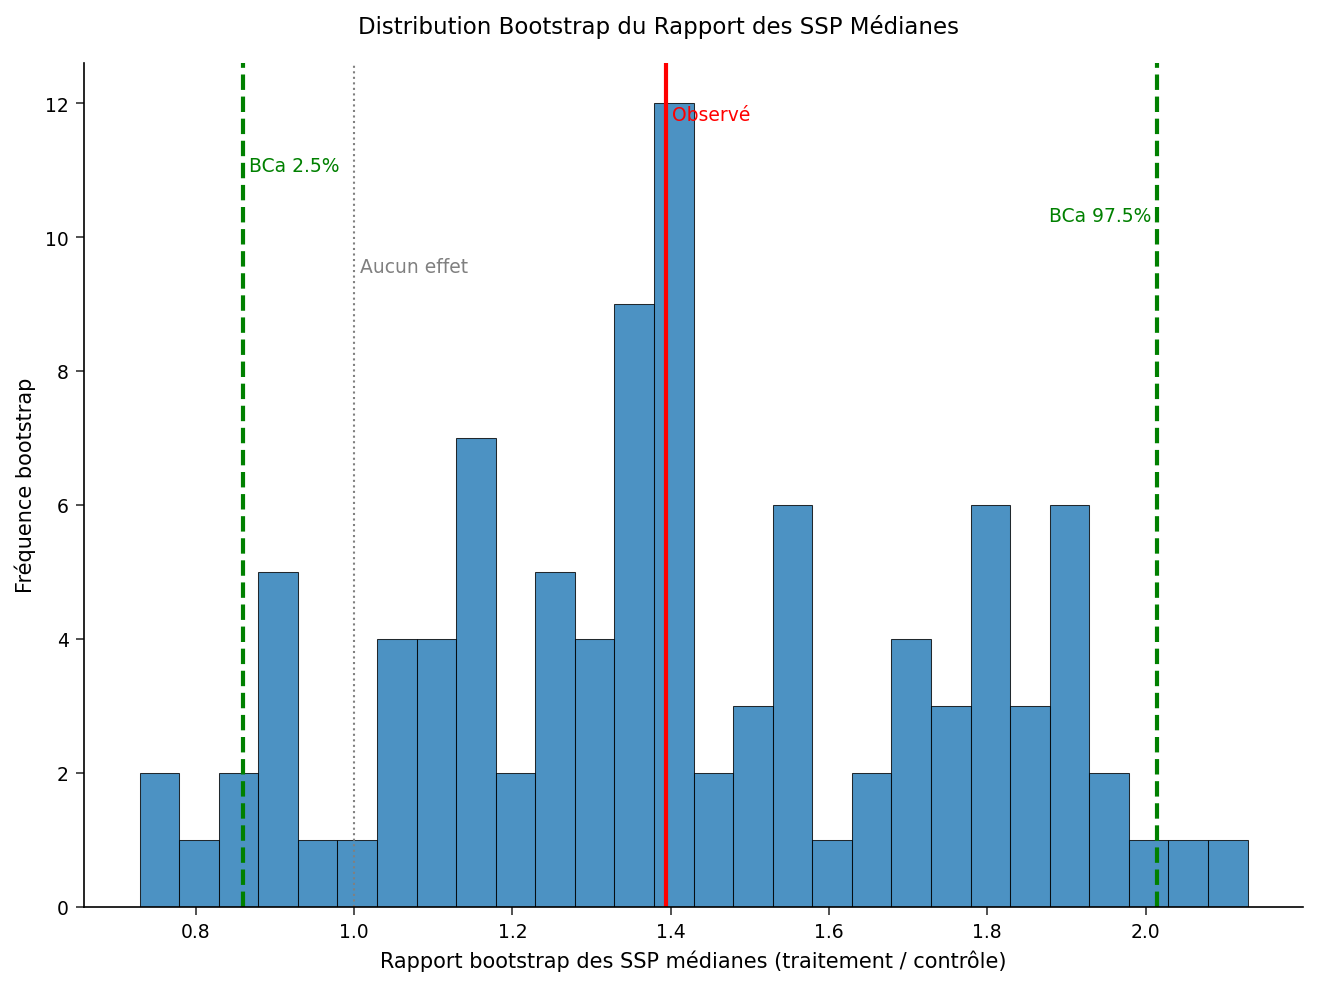

In [5]:
/* --------------------------------------------------------
   Distribution bootstrap du rapport des SSP médianes, avec
   l'estimation observée et l'intervalle BCa marqués.
   -------------------------------------------------------- */
PROCÉDURE SGPLOT DONNÉES=work.bootstrap_results;
    HISTOGRAM RATIO / BINWIDTH=0.05
        fillattrs=(color=steelblue) TRANSPARENCY=0.2;
    REFLINE obs_ratio / AXIS=x
        LINEATTRS=(color=red thickness=2) ÉTIQUETTE='Observé';
    REFLINE bca_lower / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        ÉTIQUETTE='BCa 2.5%';
    REFLINE bca_upper / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        ÉTIQUETTE='BCa 97.5%';
    REFLINE 1 / AXIS=x
        LINEATTRS=(color=gray thickness=1 pattern=dot)
        ÉTIQUETTE='Aucun effet';
    XAXIS ÉTIQUETTE='Rapport bootstrap des SSP médianes (traitement / contrôle)';
    YAXIS ÉTIQUETTE='Fréquence bootstrap';
    TITRE 'Distribution Bootstrap du Rapport des SSP Médianes';
EXÉCUTER;

---


### Interprétation

Dans cette cohorte, la SSP médiane observée sur les temps d'événement est de **9.9 mois** dans le bras traitement et **7.1 mois** dans le bras contrôle, soit un **rapport de 1.394** — la médiane de SSP du bras expérimental est environ 39% plus longue. Le programme IML a rééchantillonné les 100 sujets 2 000 fois ; les 2 000 rééchantillonnages ont tous produit un rapport défini.

L'**intervalle de confiance BCa à 95% pour le rapport est [0.86, 2.01]**, contre un intervalle percentile simple de **[0.82, 1.97]**. Les deux intervalles **incluent 1.0**, donc à cette taille d'échantillon — environ 50 sujets par bras, réduits encore aux temps d'événement observés — le bénéfice apparent n'est **pas concluant statistiquement**. C'est le message honnête de cette analyse : une estimation ponctuelle favorable au traitement, mais avec suffisamment d'incertitude de rééchantillonnage pour qu'on ne puisse écarter l'absence d'effet du traitement.

Les diagnostics BCa quantifient l'ampleur du déplacement des bornes par la correction. Le terme de biais est faible (**z<sub>0</sub> = 0.085** : environ 53% des rééchantillonnages sont tombés en dessous du rapport observé, proche du 50% symétrique), et l'accélération est proche de zéro (**a&#770; = -0.002**), indiquant que le rapport des SSP médianes n'est que faiblement influencé par des sujets individuels. Avec z<sub>0</sub> et a&#770; tous deux faibles, BCa ne déplace l'intervalle que légèrement vers le haut par rapport à l'intervalle percentile — exactement la correction modeste que prédisent ces diagnostics.

Un essai plus large resserrerait cet intervalle. Avec 50 sujets par bras, le bootstrap rapporte correctement que les données sont compatibles avec tout, d'un petit renversement à un doublement de la SSP médiane, ce qui explique pourquoi une étude dimensionnée pour détecter une différence de SSP de cette ampleur nécessite bien plus de 100 sujets.

---


In [6]:
/* --------------------------------------------------------
   Exporter la distribution bootstrap pour une annexe de rapport.
   -------------------------------------------------------- */
PROCÉDURE EXPORT DONNÉES=work.bootstrap_results
    OUTFILE='pfs_bootstrap_ci_results.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;


NOTE: PROC EXPORT data=work.bootstrap_results outfile=pfs_bootstrap_ci_results.csv

NOTE: Exported 100 rows to pfs_bootstrap_ci_results.csv.


---


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Propulsé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>